
---

# Part A — Step 1: single-trajectory neural ODE

One oscillator (δ=0.5, γ=0.5, ω=1.7), one trajectory from the barrier top. Establishes the MLP vector-field learner, phase encoding, and the wrong-well failure that motivates Step 2.

---


# Duffing Neural ODE — Step 1: single trajectory

Learn the vector field of the forced Duffing oscillator

$$\ddot{x} + \delta \dot{x} - x + x^3 = \gamma \cos(\omega t)$$

from data alone, at one fixed parameter point $\delta=0.5$, $\gamma=0.5$, $\omega=1.7$ (one-well periodic for every initial condition, per the regime atlas) and one fixed initial condition $(x_0, \dot{x}_0) = (0, 0)$ — balanced on top of the potential barrier.

**Setup:** the network $f_\theta(x, \dot{x}, \cos\omega t, \sin\omega t) \to (\dot{x}, \ddot{x})$ plays the role of the right-hand side of the ODE. The forcing phase enters as $(\cos\omega t, \sin\omega t)$ rather than raw $t$ so that time never leaves the training distribution and long rollouts stay legitimate.

**Training:** single-step — from each observed state, integrate $f_\theta$ one save-step forward with RK4 and match the next observed state.

**Evaluation:** teacher-forced one-step error, free rollout vs truth, rollout past the training horizon, and a learned-vs-true vector field comparison.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

# System: x'' + delta x' - x + x^3 = gamma cos(omega t)
DELTA, GAMMA, OMEGA = 0.5, 0.5, 1.7
IC = jnp.array([0.0, 0.0])

def true_rhs(s, t):
    x, v = s
    return jnp.array([v, -DELTA * v + x - x**3 + GAMMA * jnp.cos(OMEGA * t)])

def rk4_step(f, s, t, dt):
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def simulate(f, s0, t0, n_save, dt_save, substeps):
    # integrate f from (s0, t0), saving every dt_save, with `substeps` RK4 steps per save
    dt = dt_save / substeps
    def sub(c, _):
        s, t = c
        return (rk4_step(f, s, t, dt), t + dt), None
    def save_step(carry, _):
        carry, _ = jax.lax.scan(sub, carry, None, length=substeps)
        return carry, carry[0]
    _, traj = jax.lax.scan(save_step, (s0, t0), None, length=n_save)
    return jnp.concatenate([s0[None], traj])

# Ground truth: 20 s, integrate dt = 0.005, save every 0.01 s
T_END, DT_INT, DT_SAVE = 20.0, 0.005, 0.01
SUBS = int(round(DT_SAVE / DT_INT))
N_SAVE = int(round(T_END / DT_SAVE))

times = np.arange(N_SAVE + 1) * DT_SAVE
data = np.asarray(simulate(true_rhs, IC, 0.0, N_SAVE, DT_SAVE, SUBS))
print('trajectory:', data.shape, ' final state:', data[-1])

trajectory: (2001, 2)  final state: [ 1.25347986 -0.01968655]


## Training data

Starting balanced on the barrier top, the trajectory falls into a well and spirals onto the limit cycle. The transient is the part that carries information about the vector field away from the attractor.

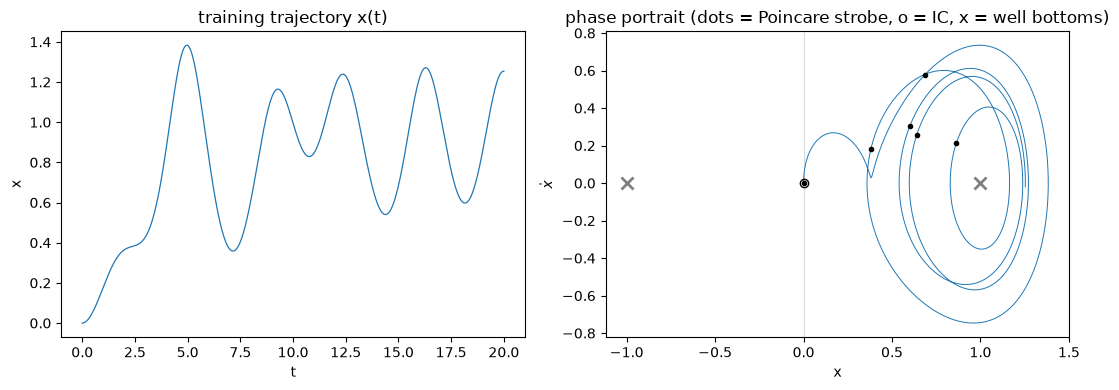

In [2]:
T_FORCE = 2 * np.pi / OMEGA          # forcing period
STROBE = np.round(np.arange(0, T_END, T_FORCE) / DT_SAVE).astype(int)

def dress_phase_axes(a):
    # atlas-gallery styling: gray x at both well bottoms, barrier line at x=0
    a.axvline(0, color='0.85', lw=0.8, zorder=0)
    a.plot([-1, 1], [0, 0], 'x', color='gray', ms=9, mew=2)
    a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(times, data[:, 0], lw=0.9)
ax[0].set_xlabel('t'); ax[0].set_ylabel('x'); ax[0].set_title('training trajectory x(t)')
ax[1].plot(data[:, 0], data[:, 1], lw=0.7)
ax[1].plot(data[STROBE, 0], data[STROBE, 1], 'k.', ms=6)
ax[1].plot([0], [0], 'o', color='k', ms=6, mfc='none')
dress_phase_axes(ax[1])
ax[1].set_title('phase portrait (dots = Poincare strobe, o = IC, x = well bottoms)')
plt.tight_layout(); plt.show()

## Model

A small MLP (4 → 64 → 64 → 2, tanh) is the learned right-hand side. tanh rather than ReLU: the function gets *integrated*, and smooth activations give smooth flows.

In [3]:
LAYERS = [4, 64, 64, 2]

def init_params(key):
    params = []
    for n_in, n_out in zip(LAYERS[:-1], LAYERS[1:]):
        key, k = jax.random.split(key)
        W = jax.random.normal(k, (n_in, n_out)) * jnp.sqrt(1.0 / n_in)
        params.append((W, jnp.zeros(n_out)))
    return params

def node_rhs(params, s, t):
    h = jnp.array([s[0], s[1], jnp.cos(OMEGA * t), jnp.sin(OMEGA * t)])
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b

n_params = sum(W.size + b.size for W, b in init_params(jax.random.PRNGKey(0)))
print('parameters:', n_params)

parameters: 4610


## Training

Single-step objective: for every consecutive pair $(s_n, s_{n+1})$ in the data, RK4-integrate $f_\theta$ one save-step forward from $s_n$ and take the MSE against $s_{n+1}$. All 2,000 pairs in one full batch, Adam with a simple learning-rate decay.

In [4]:
states = jnp.asarray(data)
t_grid = jnp.asarray(times)
s_now, s_next, t_now = states[:-1], states[1:], t_grid[:-1]

def one_step(params, s, t):
    return rk4_step(lambda s_, t_: node_rhs(params, s_, t_), s, t, DT_SAVE)

def loss_fn(params):
    pred = jax.vmap(lambda s, t: one_step(params, s, t))(s_now, t_now)
    return jnp.mean((pred - s_next) ** 2)

def adam_update(params, grads, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = jax.tree.map(lambda m_, g: b1 * m_ + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda v_, g: b2 * v_ + (1 - b2) * g * g, v, grads)
    mhat = jax.tree.map(lambda m_: m_ / (1 - b1 ** step), m)
    vhat = jax.tree.map(lambda v_: v_ / (1 - b2 ** step), v)
    new = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                       params, mhat, vhat)
    return new, m, v

@jax.jit
def train_step(params, m, v, step, lr):
    loss, grads = jax.value_and_grad(loss_fn)(params)
    params, m, v = adam_update(params, grads, m, v, step, lr)
    return params, m, v, loss

params = init_params(jax.random.PRNGKey(0))
m = jax.tree.map(jnp.zeros_like, params)
v = jax.tree.map(jnp.zeros_like, params)

N_STEPS = 6000
for i in range(1, N_STEPS + 1):
    if i <= 4000:
        lr = 1e-3
    else:
        lr = 1e-4
    params, m, v, loss = train_step(params, m, v, float(i), lr)
    if i == 1 or i % 500 == 0:
        print(f'step {i:5d}   lr {lr:.0e}   loss {loss:.3e}')

step     1   lr 1e-03   loss 5.429e-05


step   500   lr 1e-03   loss 2.827e-07


step  1000   lr 1e-03   loss 8.275e-08


step  1500   lr 1e-03   loss 2.649e-08


step  2000   lr 1e-03   loss 5.898e-09


...

step  4000   lr 1e-03   loss 6.029e-10


step  4500   lr 1e-04   loss 5.870e-10


step  5000   lr 1e-04   loss 5.700e-10


step  5500   lr 1e-04   loss 5.517e-10


step  6000   lr 1e-04   loss 5.325e-10


## Evaluation 1 — teacher-forced one-step error

Prediction error one step ahead, starting from the *true* state each time. This only confirms the fit worked; it says nothing yet about rollout stability.

one-step error: median 2.66e-05   max 1.48e-04


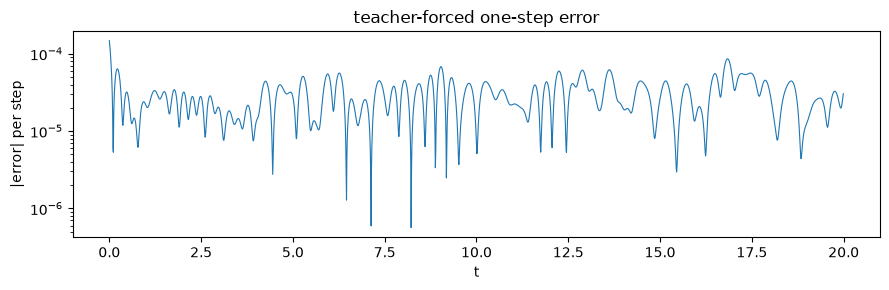

In [5]:
pred = np.asarray(jax.vmap(lambda s, t: one_step(params, s, t))(s_now, t_now))
err = np.linalg.norm(pred - np.asarray(s_next), axis=1)
print(f'one-step error: median {np.median(err):.2e}   max {err.max():.2e}')

plt.figure(figsize=(9, 3))
plt.semilogy(times[:-1], err, lw=0.8)
plt.xlabel('t'); plt.ylabel('|error| per step'); plt.title('teacher-forced one-step error')
plt.tight_layout(); plt.show()

## Evaluation 2 — free rollout

The real exam: integrate the learned vector field from the IC for the full 20 s with **no access to the data**, and overlay on the truth. Errors compound step to step, so any weakness shows up as drift.

rollout error: mean 3.25e-03   final 1.30e-02


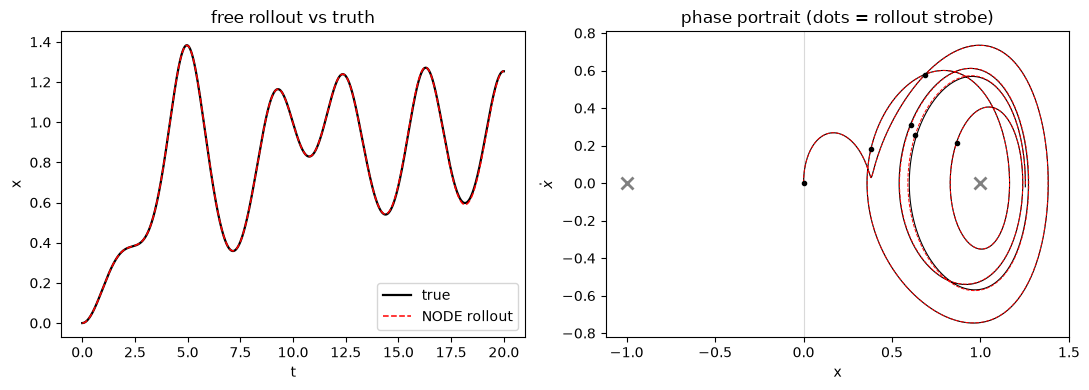

In [6]:
node_f = lambda s, t: node_rhs(params, s, t)
roll = np.asarray(simulate(node_f, IC, 0.0, N_SAVE, DT_SAVE, 1))
roll_err = np.linalg.norm(roll - data, axis=1)
print(f'rollout error: mean {roll_err.mean():.2e}   final {roll_err[-1]:.2e}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(times, data[:, 0], 'k', lw=1.6, label='true')
ax[0].plot(times, roll[:, 0], 'r--', lw=1.1, label='NODE rollout')
ax[0].set_xlabel('t'); ax[0].set_ylabel('x'); ax[0].legend()
ax[0].set_title('free rollout vs truth')
ax[1].plot(data[:, 0], data[:, 1], 'k', lw=0.8)
ax[1].plot(roll[:, 0], roll[:, 1], 'r--', lw=0.7)
ax[1].plot(roll[STROBE, 0], roll[STROBE, 1], 'k.', ms=6)
dress_phase_axes(ax[1])
ax[1].set_title('phase portrait (dots = rollout strobe)')
plt.tight_layout(); plt.show()

## Evaluation 3 — past the training horizon

Rollout to 40 s — twice the training window. Because time enters only as $(\cos\omega t, \sin\omega t)$, $t > 20$ is *not* extrapolation for the network: the inputs stay on the same circle it trained on, so it should keep tracing the limit cycle indefinitely.

error beyond training horizon: mean 4.59e-03   max 1.29e-02


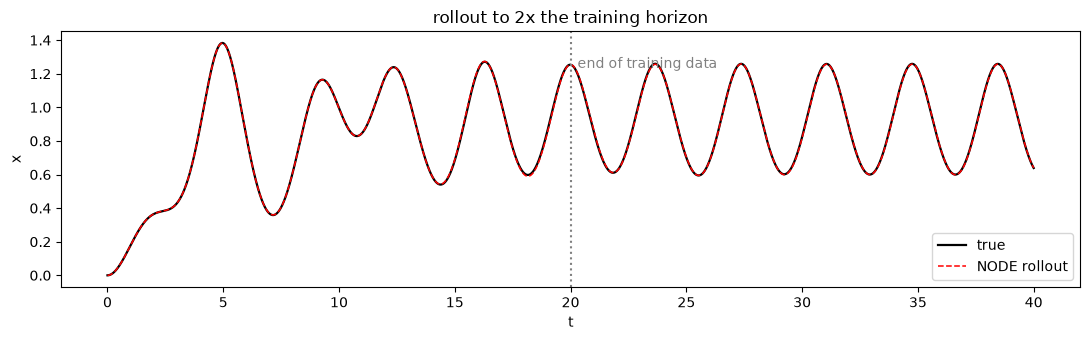

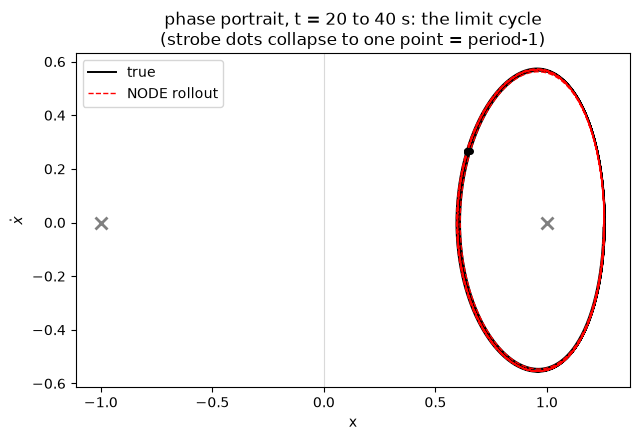

In [7]:
N_LONG = int(round(40.0 / DT_SAVE))
t_long = np.arange(N_LONG + 1) * DT_SAVE
true_long = np.asarray(simulate(true_rhs, IC, 0.0, N_LONG, DT_SAVE, SUBS))
roll_long = np.asarray(simulate(node_f, IC, 0.0, N_LONG, DT_SAVE, 1))
tail_err = np.linalg.norm(roll_long - true_long, axis=1)[t_long > T_END]
print(f'error beyond training horizon: mean {tail_err.mean():.2e}   max {tail_err.max():.2e}')

plt.figure(figsize=(11, 3.5))
plt.plot(t_long, true_long[:, 0], 'k', lw=1.6, label='true')
plt.plot(t_long, roll_long[:, 0], 'r--', lw=1.1, label='NODE rollout')
plt.axvline(T_END, color='gray', ls=':', lw=1.5)
plt.text(T_END + 0.3, plt.ylim()[1] * 0.85, 'end of training data', color='gray')
plt.xlabel('t'); plt.ylabel('x'); plt.legend(loc='lower right')
plt.title('rollout to 2x the training horizon')
plt.tight_layout(); plt.show()

# phase portrait of the settled part only (t in [20, 40]): the transient spiral is
# gone and what remains is the limit cycle — a single closed loop
late = t_long >= T_END
strobe_long = np.round(np.arange(0, 40.0, T_FORCE) / DT_SAVE).astype(int)
strobe_late = strobe_long[t_long[strobe_long] >= T_END]
fig, a = plt.subplots(figsize=(6.5, 4.5))
a.plot(true_long[late, 0], true_long[late, 1], 'k', lw=1.4, label='true')
a.plot(roll_long[late, 0], roll_long[late, 1], 'r--', lw=1.0, label='NODE rollout')
a.plot(roll_long[strobe_late, 0], roll_long[strobe_late, 1], 'k.', ms=8)
dress_phase_axes(a)
a.legend()
a.set_title('phase portrait, t = 20 to 40 s: the limit cycle\n'
            '(strobe dots collapse to one point = period-1)')
plt.tight_layout(); plt.show()

## Evaluation 4 — where is the learned vector field actually right?

Compare the learned acceleration $f_\theta \to \ddot{x}$ against the true $-\delta\dot{x} + x - x^3 + \gamma\cos(\omega t)$ over the whole $(x, \dot{x})$ plane at forcing phase $t=0$. The white curve is the single training trajectory. Expect: accurate inside the tube the trajectory painted, wrong elsewhere — the network only knows the vector field where it has seen data. This is the picture that motivates Step 2 (many initial conditions = paint the whole region).

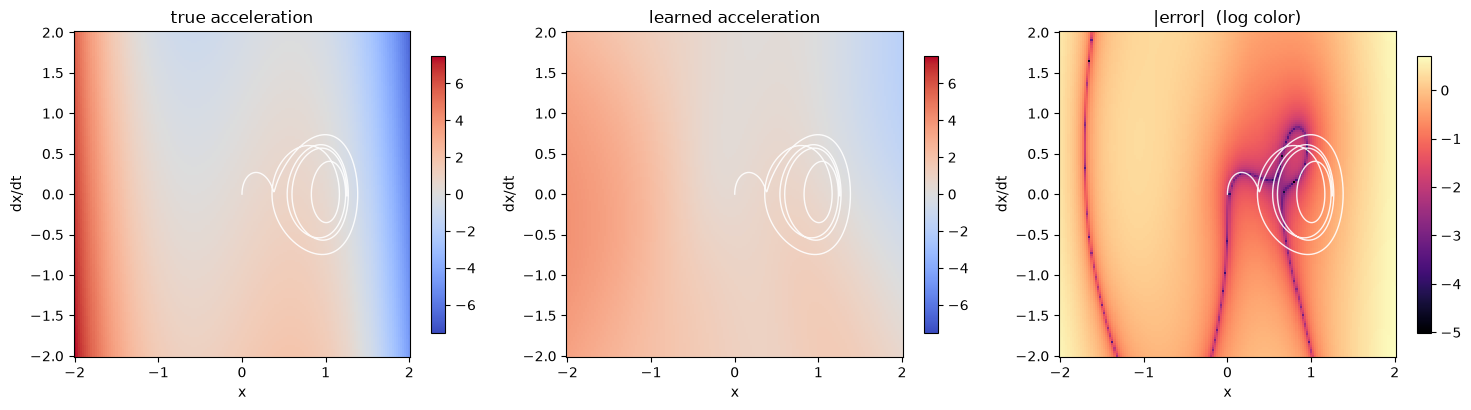

In [8]:
xs = np.linspace(-2.0, 2.0, 161)
vs = np.linspace(-2.0, 2.0, 161)
X, V = np.meshgrid(xs, vs)
grid = jnp.stack([jnp.asarray(X.ravel()), jnp.asarray(V.ravel())], axis=1)

learned_acc = np.asarray(jax.vmap(lambda s: node_rhs(params, s, 0.0))(grid))[:, 1]
learned_acc = learned_acc.reshape(X.shape)
true_acc = -DELTA * V + X - X**3 + GAMMA * np.cos(0.0)
abs_err = np.abs(learned_acc - true_acc)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
lim = np.abs(true_acc).max()
for a, Z, title, cmap, vmin, vmax in [
        (ax[0], true_acc, 'true acceleration', 'coolwarm', -lim, lim),
        (ax[1], learned_acc, 'learned acceleration', 'coolwarm', -lim, lim),
        (ax[2], abs_err, '|error|  (log color)', 'magma', None, None)]:
    if title.startswith('|'):
        im = a.pcolormesh(X, V, np.log10(Z + 1e-6), cmap=cmap)
    else:
        im = a.pcolormesh(X, V, Z, cmap=cmap, vmin=vmin, vmax=vmax)
    a.plot(data[:, 0], data[:, 1], 'w', lw=1.0, alpha=0.9)
    a.set_xlabel('x'); a.set_ylabel('dx/dt'); a.set_title(title)
    fig.colorbar(im, ax=a, shrink=0.85)
plt.tight_layout(); plt.show()

## Evaluation 5 — unseen initial conditions

The network only saw one trajectory. Roll it out from ICs it never trained on, spanning near-to-far from the training tube:

- **(0.8, 0.3)** — inside the tube the training spiral painted: should still work
- **(0.0, 0.8)** — off the tube, but its transient passes near painted territory: partial credit at best
- **(−0.5, 0.0)** — the true trajectory settles into the **left well**, which the network has never seen: expect nonsense

IC (0.8, 0.3):  mean err 8.09e-03   final err 6.66e-03
IC (0.0, 0.8):  mean err 3.81e-02   final err 4.13e-03
IC (-0.5, 0.0):  mean err 1.67e+00   final err 1.86e+00


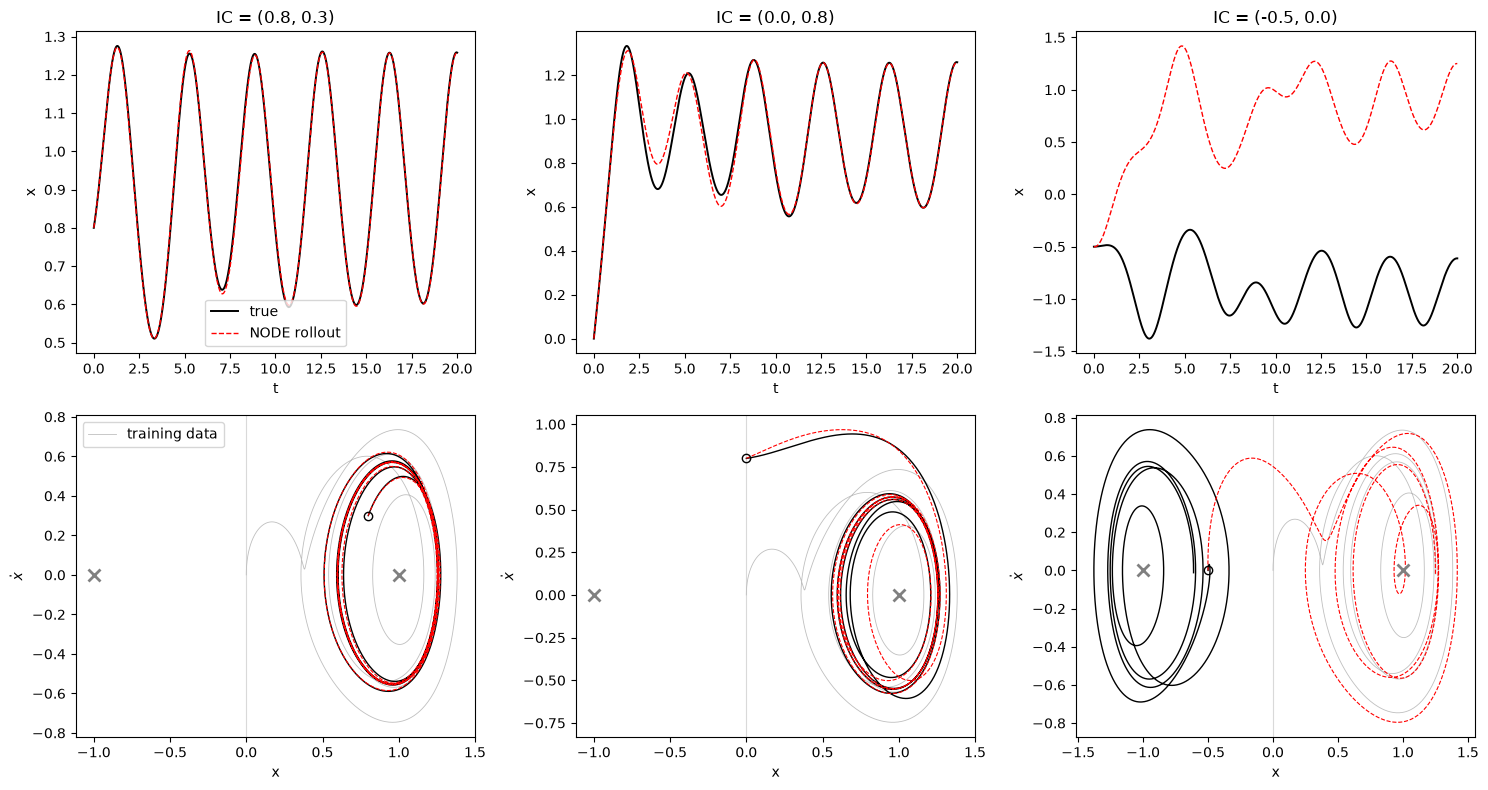

In [9]:
TEST_ICS = [(0.8, 0.3), (0.0, 0.8), (-0.5, 0.0)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ic in enumerate(TEST_ICS):
    s0 = jnp.array(ic)
    tru = np.asarray(simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
    rol = np.asarray(simulate(node_f, s0, 0.0, N_SAVE, DT_SAVE, 1))
    err = np.linalg.norm(rol - tru, axis=1)
    print(f'IC {ic}:  mean err {err.mean():.2e}   final err {err[-1]:.2e}')

    a = axes[0, col]
    a.plot(times, tru[:, 0], 'k', lw=1.4, label='true')
    a.plot(times, rol[:, 0], 'r--', lw=1.0, label='NODE rollout')
    a.set_xlabel('t'); a.set_ylabel('x')
    a.set_title(f'IC = {ic}')
    if col == 0:
        a.legend()

    a = axes[1, col]
    a.plot(data[:, 0], data[:, 1], color='0.75', lw=0.6, label='training data')
    a.plot(tru[:, 0], tru[:, 1], 'k', lw=1.0)
    a.plot(rol[:, 0], rol[:, 1], 'r--', lw=0.8)
    a.plot([ic[0]], [ic[1]], 'o', color='k', ms=6, mfc='none')
    dress_phase_axes(a)
    if col == 0:
        a.legend()
plt.tight_layout(); plt.show()


---

# Part B — Step 2: the 63-IC grid

Same oscillator, 9×7 IC grid. Held-out ICs pass, and the extrapolation-ray methodology is introduced. Each part is self-contained (re-defines its own globals).

---


# Duffing Neural ODE — Step 2: many initial conditions

Same system and parameter point as Step 1 ($\delta=0.5$, $\gamma=0.5$, $\omega=1.7$), but now the network trains on trajectories from a **9×7 grid of initial conditions** covering $x_0 \in [-0.75, 0.75]$, $\dot{x}_0 \in [-0.4, 0.4]$ — 63 trajectories, 20 s each, straddling both wells.

Goals:
1. **Interpolation** — held-out ICs inside the box (off the training grid) should now work, including $(-0.5, 0)$ which failed completely in Step 1.
2. **Extrapolation breakdown** — march ICs along rays out of the box and measure where the rollout error takes off.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

DELTA, GAMMA, OMEGA = 0.5, 0.5, 1.7

def true_rhs(s, t):
    x, v = s
    return jnp.array([v, -DELTA * v + x - x**3 + GAMMA * jnp.cos(OMEGA * t)])

def rk4_step(f, s, t, dt):
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def simulate(f, s0, t0, n_save, dt_save, substeps):
    dt = dt_save / substeps
    def sub(c, _):
        s, t = c
        return (rk4_step(f, s, t, dt), t + dt), None
    def save_step(carry, _):
        carry, _ = jax.lax.scan(sub, carry, None, length=substeps)
        return carry, carry[0]
    _, traj = jax.lax.scan(save_step, (s0, t0), None, length=n_save)
    return jnp.concatenate([s0[None], traj])

T_END, DT_INT, DT_SAVE = 20.0, 0.005, 0.01
SUBS = int(round(DT_SAVE / DT_INT))
N_SAVE = int(round(T_END / DT_SAVE))
times = np.arange(N_SAVE + 1) * DT_SAVE

# 9x7 grid of ICs over the training box
X0_LIM, V0_LIM = 0.75, 0.4
ic_grid = np.stack(np.meshgrid(np.linspace(-X0_LIM, X0_LIM, 9),
                               np.linspace(-V0_LIM, V0_LIM, 7),
                               indexing='ij'), axis=-1).reshape(-1, 2)
print('training ICs:', ic_grid.shape)

sim_batch = jax.vmap(lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
trajs = np.asarray(sim_batch(jnp.asarray(ic_grid)))
print('trajectories:', trajs.shape)
n_right = int((trajs[:, -1, 0] > 0).sum())
print(f'settle to right well: {n_right}/63, left well: {63 - n_right}/63')

training ICs: (63, 2)
trajectories: (63, 2001, 2)
settle to right well: 35/63, left well: 28/63


## Training data coverage

All 63 trajectories in the phase plane. This is the "painted region" — the network can only be trusted where there is paint. Note the trajectories overshoot the IC box (black rectangle): coverage is set by where trajectories *go*, not where they start.

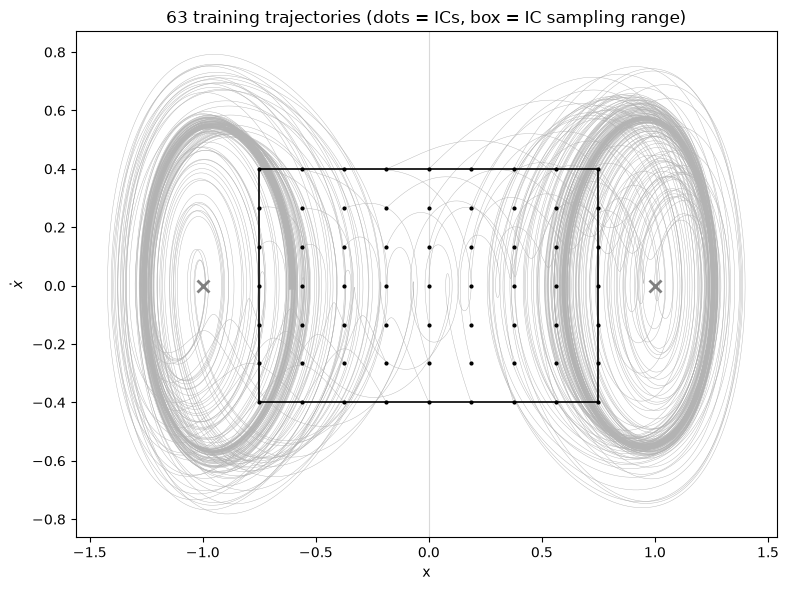

In [2]:
T_FORCE = 2 * np.pi / OMEGA

def dress_phase_axes(a):
    a.axvline(0, color='0.85', lw=0.8, zorder=0)
    a.plot([-1, 1], [0, 0], 'x', color='gray', ms=9, mew=2)
    a.set_xlabel('x'); a.set_ylabel(r'$\dot{x}$')

fig, a = plt.subplots(figsize=(8, 6))
for tr in trajs:
    a.plot(tr[:, 0], tr[:, 1], color='0.7', lw=0.3, zorder=1)
a.plot(ic_grid[:, 0], ic_grid[:, 1], 'k.', ms=4, zorder=3)
a.add_patch(plt.Rectangle((-X0_LIM, -V0_LIM), 2 * X0_LIM, 2 * V0_LIM,
                          fill=False, edgecolor='k', lw=1.2, zorder=3))
dress_phase_axes(a)
a.set_title('63 training trajectories (dots = ICs, box = IC sampling range)')
plt.tight_layout(); plt.show()

## Model and training

Identical architecture to Step 1 (4 → 64 → 64 → 2, tanh; inputs $x, \dot{x}, \cos\omega t, \sin\omega t$). The dataset is now ~126k step pairs, so training is minibatched: 16,384 random pairs per Adam step.

In [3]:
LAYERS = [4, 64, 64, 2]

def init_params(key):
    params = []
    for n_in, n_out in zip(LAYERS[:-1], LAYERS[1:]):
        key, k = jax.random.split(key)
        W = jax.random.normal(k, (n_in, n_out)) * jnp.sqrt(1.0 / n_in)
        params.append((W, jnp.zeros(n_out)))
    return params

def node_rhs(params, s, t):
    h = jnp.array([s[0], s[1], jnp.cos(OMEGA * t), jnp.sin(OMEGA * t)])
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b

# flatten all (state_n, state_n+1, t_n) pairs across trajectories
s_now = jnp.asarray(trajs[:, :-1, :].reshape(-1, 2))
s_next = jnp.asarray(trajs[:, 1:, :].reshape(-1, 2))
t_now = jnp.asarray(np.tile(times[:-1], len(ic_grid)))
N_PAIRS = s_now.shape[0]
print('training pairs:', N_PAIRS)

def one_step(params, s, t):
    return rk4_step(lambda s_, t_: node_rhs(params, s_, t_), s, t, DT_SAVE)

def loss_on(params, sb, snb, tb):
    pred = jax.vmap(lambda s, t: one_step(params, s, t))(sb, tb)
    return jnp.mean((pred - snb) ** 2)

def adam_update(params, grads, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = jax.tree.map(lambda m_, g: b1 * m_ + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda v_, g: b2 * v_ + (1 - b2) * g * g, v, grads)
    mhat = jax.tree.map(lambda m_: m_ / (1 - b1 ** step), m)
    vhat = jax.tree.map(lambda v_: v_ / (1 - b2 ** step), v)
    new = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                       params, mhat, vhat)
    return new, m, v

BATCH = 16384

@jax.jit
def train_step(params, m, v, step, lr, key):
    idx = jax.random.randint(key, (BATCH,), 0, N_PAIRS)
    loss, grads = jax.value_and_grad(loss_on)(params, s_now[idx], s_next[idx],
                                              t_now[idx])
    params, m, v = adam_update(params, grads, m, v, step, lr)
    return params, m, v, loss

params = init_params(jax.random.PRNGKey(0))
m = jax.tree.map(jnp.zeros_like, params)
v = jax.tree.map(jnp.zeros_like, params)
base_key = jax.random.PRNGKey(1)

N_STEPS = 12000
for i in range(1, N_STEPS + 1):
    if i <= 8000:
        lr = 1e-3
    else:
        lr = 1e-4
    params, m, v, loss = train_step(params, m, v, float(i), lr,
                                    jax.random.fold_in(base_key, i))
    if i == 1 or i % 1000 == 0:
        print(f'step {i:6d}   lr {lr:.0e}   batch loss {loss:.3e}')

full_loss = loss_on(params, s_now, s_next, t_now)
print(f'final loss over all {N_PAIRS} pairs: {full_loss:.3e}')

training pairs: 126000


step      1   lr 1e-03   batch loss 5.390e-05


step   1000   lr 1e-03   batch loss 1.289e-07


step   2000   lr 1e-03   batch loss 3.912e-08


step   3000   lr 1e-03   batch loss 1.478e-08


...

step   9000   lr 1e-04   batch loss 2.062e-09


step  10000   lr 1e-04   batch loss 2.098e-09


step  11000   lr 1e-04   batch loss 1.892e-09


step  12000   lr 1e-04   batch loss 1.844e-09


final loss over all 126000 pairs: 1.804e-09


## Test 1 — interpolation: unseen ICs inside the box

Five held-out ICs, none on the 9×7 training grid. The last one, $(-0.5, 0)$, is the IC that failed by ~500× in Step 1 (the network had never seen the left well). Now the left well is painted.

In [4]:
node_f = lambda s, t: node_rhs(params, s, t)

INTERP_ICS = [(0.33, 0.17), (-0.61, -0.29), (0.05, -0.37), (0.7, 0.35), (-0.5, 0.0)]
results = {}
for ic in INTERP_ICS:
    s0 = jnp.array(ic)
    tru = np.asarray(simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
    rol = np.asarray(simulate(node_f, s0, 0.0, N_SAVE, DT_SAVE, 1))
    err = np.linalg.norm(rol - tru, axis=1)
    results[ic] = (tru, rol, err)
    same_well = (tru[-1, 0] > 0) == (rol[-1, 0] > 0)
    print(f'IC {str(ic):15s} mean err {err.mean():.2e}   final err {err[-1]:.2e}'
          f'   same final well: {same_well}')

IC (0.33, 0.17)    mean err 3.24e-03   final err 7.19e-04   same final well: True


IC (-0.61, -0.29)  mean err 3.54e-03   final err 3.92e-03   same final well: True
IC (0.05, -0.37)   mean err 6.81e-03   final err 1.52e-03   same final well: True


IC (0.7, 0.35)     mean err 2.51e-03   final err 8.85e-04   same final well: True


IC (-0.5, 0.0)     mean err 8.16e-03   final err 4.02e-03   same final well: True


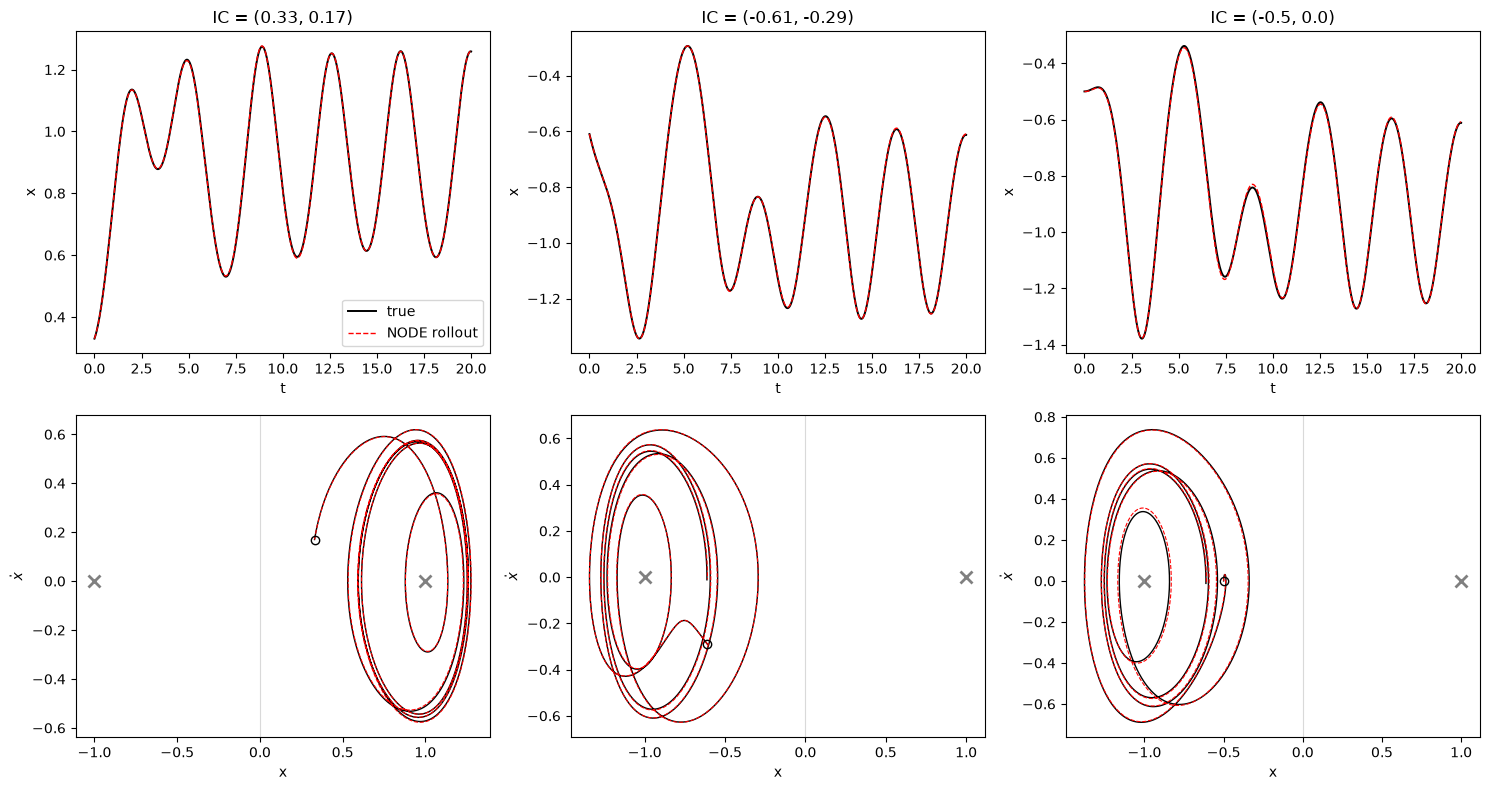

In [5]:
SHOW = [(0.33, 0.17), (-0.61, -0.29), (-0.5, 0.0)]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ic in enumerate(SHOW):
    tru, rol, err = results[ic]
    a = axes[0, col]
    a.plot(times, tru[:, 0], 'k', lw=1.4, label='true')
    a.plot(times, rol[:, 0], 'r--', lw=1.0, label='NODE rollout')
    a.set_xlabel('t'); a.set_ylabel('x'); a.set_title(f'IC = {ic}')
    if col == 0:
        a.legend()
    a = axes[1, col]
    a.plot(tru[:, 0], tru[:, 1], 'k', lw=1.0)
    a.plot(rol[:, 0], rol[:, 1], 'r--', lw=0.8)
    a.plot([ic[0]], [ic[1]], 'o', color='k', ms=6, mfc='none')
    dress_phase_axes(a)
plt.tight_layout(); plt.show()

## Test 2 — where does extrapolation break down?

March the IC along two rays out of the box and measure the mean rollout error at each starting point:

- along $x_0$ with $\dot{x}_0 = 0$, from $-2.5$ to $2.5$ (box edge at $\pm 0.75$)
- along $\dot{x}_0$ with $x_0 = 0$, from $-1.5$ to $1.5$ (box edge at $\pm 0.4$)

Expect low flat error inside the box, staying low a bit *past* the edge (training trajectories overshoot the box, so the painted region is bigger), then a takeoff once the IC starts in truly unpainted territory. Spikes can also mark **basin boundaries**: there a tiny model error flips the trajectory into the wrong well, so the error jumps to order 1 even when the vector field is only slightly off.

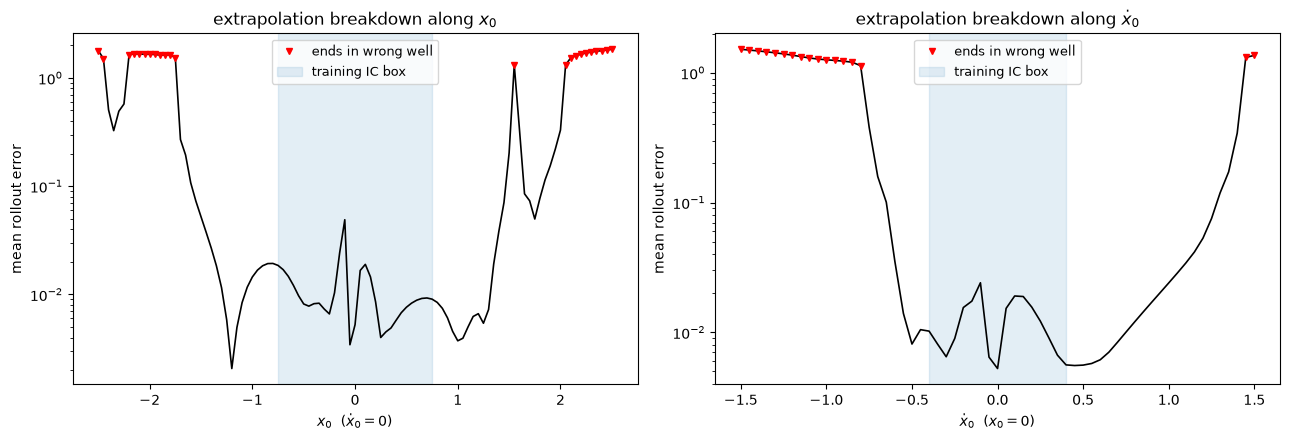

In [6]:
def ray_errors(ics):
    ics = jnp.asarray(ics)
    tru = np.asarray(jax.vmap(
        lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))(ics))
    rol = np.asarray(jax.vmap(
        lambda s0: simulate(node_f, s0, 0.0, N_SAVE, DT_SAVE, 1))(ics))
    err = np.linalg.norm(rol - tru, axis=2).mean(axis=1)
    wrong_well = (tru[:, -1, 0] > 0) != (rol[:, -1, 0] > 0)
    return err, wrong_well

x_ray = np.linspace(-2.5, 2.5, 101)
v_ray = np.linspace(-1.5, 1.5, 61)
err_x, ww_x = ray_errors(np.stack([x_ray, np.zeros_like(x_ray)], axis=1))
err_v, ww_v = ray_errors(np.stack([np.zeros_like(v_ray), v_ray], axis=1))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, ray, err, ww, lim, name in [
        (ax[0], x_ray, err_x, ww_x, X0_LIM, '$x_0$  ($\\dot{x}_0 = 0$)'),
        (ax[1], v_ray, err_v, ww_v, V0_LIM, '$\\dot{x}_0$  ($x_0 = 0$)')]:
    a.semilogy(ray, err, 'k', lw=1.2)
    a.semilogy(ray[ww], err[ww], 'rv', ms=5, label='ends in wrong well')
    a.axvspan(-lim, lim, color='tab:blue', alpha=0.12, label='training IC box')
    a.set_xlabel(name); a.set_ylabel('mean rollout error')
    a.legend(loc='upper center', fontsize=9)
ax[0].set_title('extrapolation breakdown along $x_0$')
ax[1].set_title('extrapolation breakdown along $\\dot{x}_0$')
plt.tight_layout(); plt.show()